<a href="https://colab.research.google.com/github/Galaxy-03/Astrometrics_Statistics_Project/blob/main/astrometircs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# data loading and data cleaning

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, bernoulli, poisson

In [ ]:
data = '/content/drive/My Drive/Colab Notebooks/Space_Missions_Dataset.csv'
df = pd.read_csv(data)

df.head()


,LaunchID,LaunchYear,RocketType,PayloadMass(kg),OrbitType,LaunchCost(Million USD),FuelConsumption(tons),FlightTime(minutes),MissionSuccess,Manufacturer
0,LNCH-001,2005,Atlas V,1589,GEO,267.42,461.41,90,Success,SpaceX
1,LNCH-002,2021,Soyuz,3880,MEO,90.73,80.04,126,Success,ISRO
2,LNCH-003,2013,Atlas V,9631,MEO,364.81,299.59,107,Success,SpaceX
3,LNCH-004,2020,Atlas V,290,LEO,393.64,192.25,137,Failure,NASA
4,LNCH-005,2017,Ariane 5,2188,HEO,84.00,352.02,140,Failure,ISRO


In [ ]:
df.describe()

,LaunchYear,PayloadMass(kg),LaunchCost(Million USD),FuelConsumption(tons),FlightTime(minutes)
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2011.530000,5339.530000,271.865200,371.422100,79.480000
std,6.982597,2776.373557,135.094433,170.751798,42.020793
min,2000.000000,290.000000,27.570000,58.890000,5.000000
25%,2005.750000,3043.250000,176.967500,226.180000,39.500000
50%,2011.000000,5349.500000,259.050000,352.215000,81.500000
75%,2018.250000,7366.750000,396.052500,509.010000,114.750000
max,2023.000000,9983.000000,494.440000,683.290000,146.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   LaunchID                 100 non-null    object 
 1   LaunchYear               100 non-null    int64  
 2   RocketType               100 non-null    object 
 3   PayloadMass(kg)          100 non-null    int64  
 4   OrbitType                100 non-null    object 
 5   LaunchCost(Million USD)  100 non-null    float64
 6   FuelConsumption(tons)    100 non-null    float64
 7   FlightTime(minutes)      100 non-null    int64  
 8   MissionSuccess           100 non-null    object 
 9   Manufacturer             100 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 7.9+ KB


In [ ]:
# finding missing values and filling them
df.isnull().sum()

,0
LaunchID,0
LaunchYear,0
RocketType,0
PayloadMass(kg),0
OrbitType,0
LaunchCost(Million USD),0
FuelConsumption(tons),0
FlightTime(minutes),0
MissionSuccess,0
Manufacturer,0


In [ ]:
# Categorical and numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['LaunchYear', 'PayloadMass(kg)', 'LaunchCost(Million USD)', 'FuelConsumption(tons)', 'FlightTime(minutes)']
Categorical Columns: ['LaunchID', 'RocketType', 'OrbitType', 'MissionSuccess', 'Manufacturer']


MEASURE OF CENTRAL TENDENCY

MEAN

In [ ]:
for col in numerical_cols:
    mean_value = np.mean(df[col])
    print(f"Column: {col}")
    print(f"Mean: {mean_value}\n")

Column: LaunchYear
Mean: 2011.53

Column: PayloadMass(kg)
Mean: 5339.53

Column: LaunchCost(Million USD)
Mean: 271.8652

Column: FuelConsumption(tons)
Mean: 371.4221

Column: FlightTime(minutes)
Mean: 79.48



MEDIAN

In [ ]:
for col in numerical_cols:
    median_value = np.median(df[col])
    print(f"Column: {col}")
    print(f"Median: {median_value}\n")

Column: LaunchYear
Median: 2011.0

Column: PayloadMass(kg)
Median: 5349.5

Column: LaunchCost(Million USD)
Median: 259.05

Column: FuelConsumption(tons)
Median: 352.21500000000003

Column: FlightTime(minutes)
Median: 81.5



MODE

In [ ]:
for col in numerical_cols:
    mode_result = stats.mode(df[col], keepdims=True)
    mode_value = mode_result.mode[0]
    print(f"Column: {col}")
    print(f"Mode: {mode_value}\n")

Column: LaunchYear
Mode: 2021

Column: PayloadMass(kg)
Mode: 859

Column: LaunchCost(Million USD)
Mode: 27.57

Column: FuelConsumption(tons)
Mode: 58.89

Column: FlightTime(minutes)
Mode: 24



MEASURE OF DISPERSION

Range

In [ ]:
for col in numerical_cols:
    range_value = np.ptp(df[col])
    print(f"Column: {col}")
    print(f"Range: {range_value}\n")

Column: LaunchYear
Range: 23

Column: PayloadMass(kg)
Range: 9693

Column: LaunchCost(Million USD)
Range: 466.87

Column: FuelConsumption(tons)
Range: 624.4

Column: FlightTime(minutes)
Range: 141



Variance


In [ ]:
for col in numerical_cols:
    var_value = np.var(df[col])
    print(f"Column: {col}")
    print(f"Variance: {var_value}\n")

Column: LaunchYear
Variance: 48.269099999999945

Column: PayloadMass(kg)
Variance: 7631167.629099999

Column: LaunchCost(Million USD)
Variance: 18068.000674960003

Column: FuelConsumption(tons)
Variance: 28864.614774590005

Column: FlightTime(minutes)
Variance: 1748.0896



Standard Deviation

In [ ]:
for col in numerical_cols:
    std_value = np.std(df[col])
    print(f"Column: {col}")
    print(f"Standard Deviation: {std_value}\n")

Column: LaunchYear
Standard Deviation: 6.9475967067756565

Column: PayloadMass(kg)
Standard Deviation: 2762.4568103592133

Column: LaunchCost(Million USD)
Standard Deviation: 134.4172633070619

Column: FuelConsumption(tons)
Standard Deviation: 169.89589393093055

Column: FlightTime(minutes)
Standard Deviation: 41.81016144431877



Quartiles

In [ ]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q2 = df[col].quantile(0.50)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    print(f"Column: {col}")
    print(f"Q1: {Q1}, Q2: {Q2}, Q3: {Q3}, IQR: {IQR}\n")


Column: LaunchYear
Q1: 2005.75, Q2: 2011.0, Q3: 2018.25, IQR: 12.5

Column: PayloadMass(kg)
Q1: 3043.25, Q2: 5349.5, Q3: 7366.75, IQR: 4323.5

Column: LaunchCost(Million USD)
Q1: 176.9675, Q2: 259.05, Q3: 396.0525, IQR: 219.085

Column: FuelConsumption(tons)
Q1: 226.18, Q2: 352.21500000000003, Q3: 509.01, IQR: 282.83

Column: FlightTime(minutes)
Q1: 39.5, Q2: 81.5, Q3: 114.75, IQR: 75.25



MEASURE OF POSITION

Kurtosis and Skewness

In [ ]:
from scipy.stats import kurtosis, skew  # Import kurtosis and skew from scipy.stats

for col in numerical_cols:
    kurt = kurtosis(df[col]) # Calculate kurtosis
    skewness = skew(df[col])  # Calculate skewness
    if skewness > 0:
        skew_type = "Positively Skewed (Right-Skewed)"
    elif skewness < 0:
        skew_type = "Negatively Skewed (Left-Skewed)"
    else:
        skew_type = "Symmetric (Normal Distribution)"
    if kurt > 3:
        kurt_type = "Leptokurtic (Heavy-Tailed Distribution)"
    elif kurt < 3:
        kurt_type = "Platykurtic (Light-Tailed Distribution)"
    else:
        kurt_type = "Mesokurtic (Normal Distribution)"
    print(f"Column: {col}")
    print(f"Kurtosis: {kurt} ({kurt_type})")
    print(f"Skewness: {skewness} ({skew_type})\n")

Column: LaunchYear
Kurtosis: -1.3037788518296576 (Platykurtic (Light-Tailed Distribution))
Skewness: 0.06301770327240182 (Positively Skewed (Right-Skewed))

Column: PayloadMass(kg)
Kurtosis: -1.032367088840412 (Platykurtic (Light-Tailed Distribution))
Skewness: -0.07546565836964517 (Negatively Skewed (Left-Skewed))

Column: LaunchCost(Million USD)
Kurtosis: -1.1131651702115182 (Platykurtic (Light-Tailed Distribution))
Skewness: -0.09790769515342679 (Negatively Skewed (Left-Skewed))

Column: FuelConsumption(tons)
Kurtosis: -1.044882746438303 (Platykurtic (Light-Tailed Distribution))
Skewness: 0.12423001248573012 (Positively Skewed (Right-Skewed))

Column: FlightTime(minutes)
Kurtosis: -1.2216039892513861 (Platykurtic (Light-Tailed Distribution))
Skewness: -0.11404430362047258 (Negatively Skewed (Left-Skewed))



Data Visualization

Bar Graph

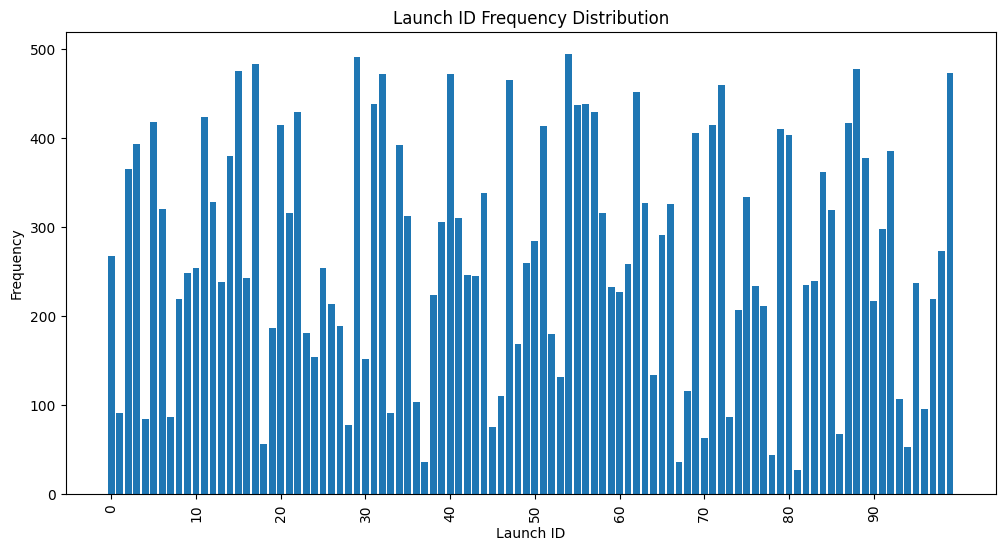

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(df['LaunchCost(Million USD)'].index, df['LaunchCost(Million USD)'].values)
plt.xlabel("Launch ID")
plt.ylabel("Frequency")
plt.title("Launch ID Frequency Distribution")
# Show every 10th label
n = 10
plt.xticks(ticks=range(0, len(df['LaunchCost(Million USD)']), n), labels=df['LaunchCost(Million USD)'].index[::n], rotation=90)

plt.show()


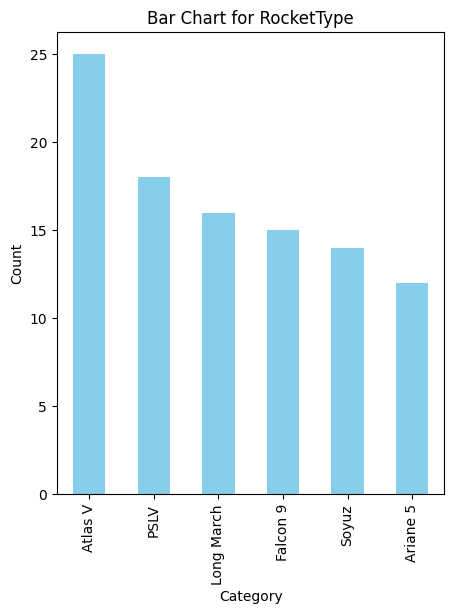

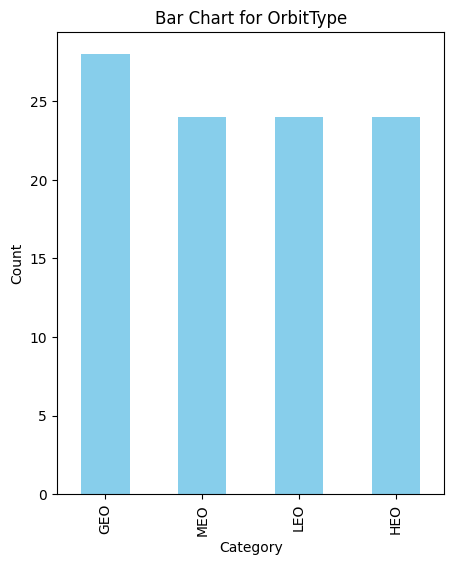

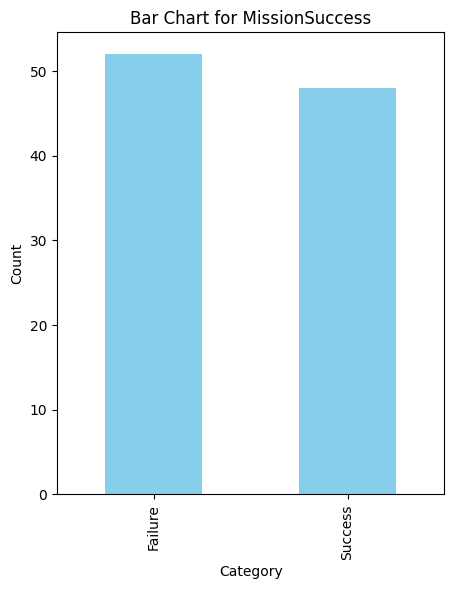

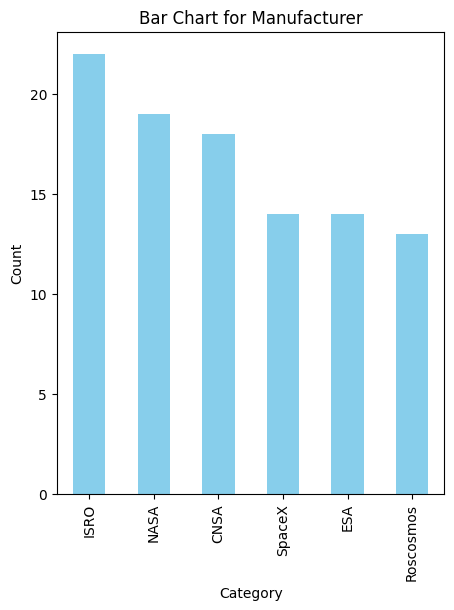

In [ ]:
cols =['RocketType', 'OrbitType', 'MissionSuccess', 'Manufacturer']
for col in cols:
    plt.figure(figsize=(5, 6))
    df[col].value_counts().plot(kind='bar', color='skyblue')
    plt.xlabel('Category')
    plt.ylabel('Count')
    plt.title(f'Bar Chart for {col}')
    plt.show()

Pie Chart

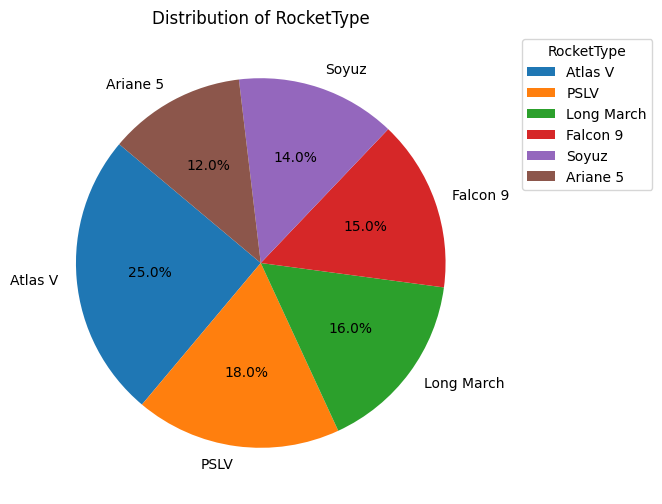

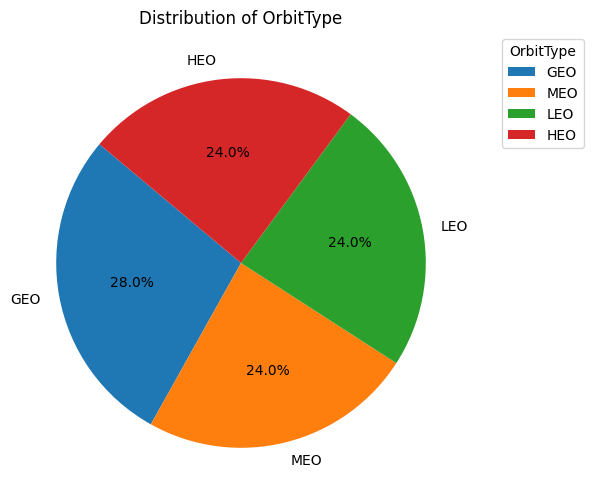

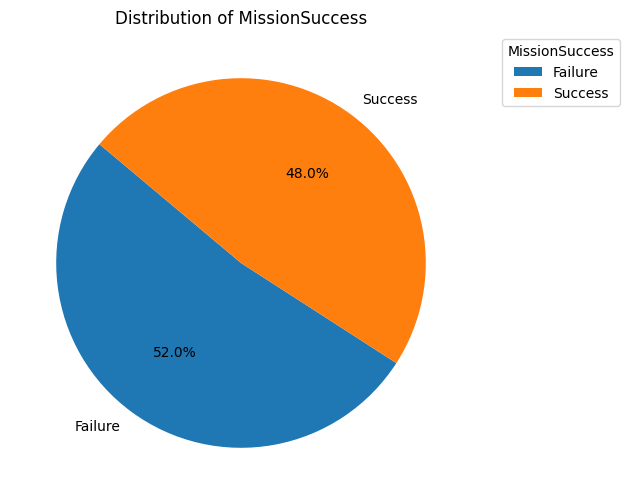

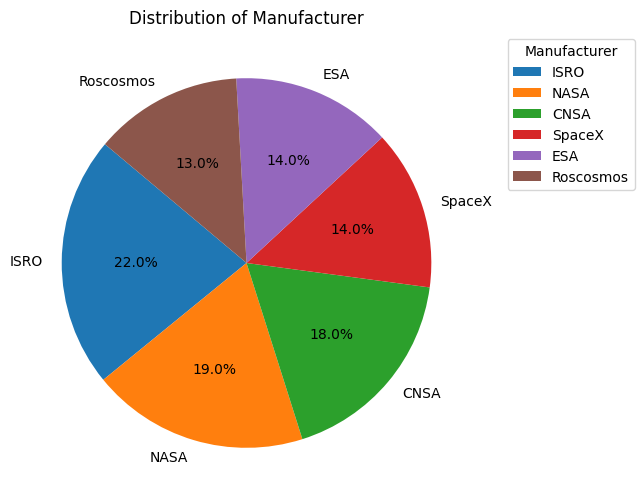

In [ ]:
for col in cols:
    plt.figure(figsize=(8, 6))

    value_counts = df[col].value_counts()
    plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=140)

    plt.title(f"Distribution of {col}")
    plt.legend(value_counts.index, title=col, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.show()


histogram

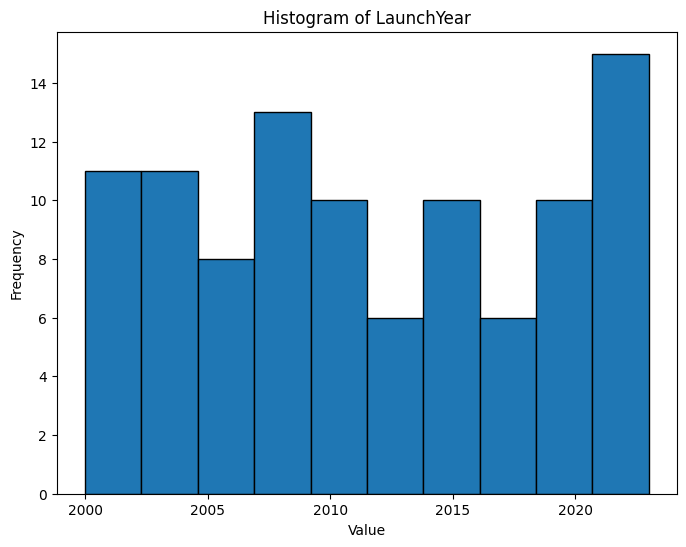

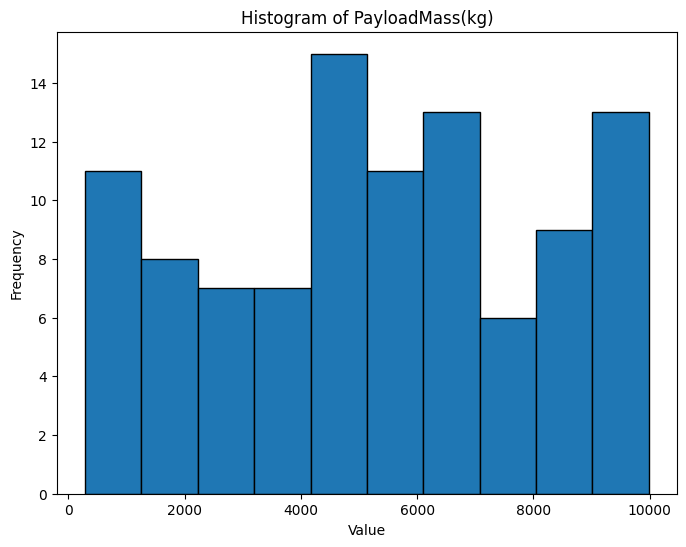

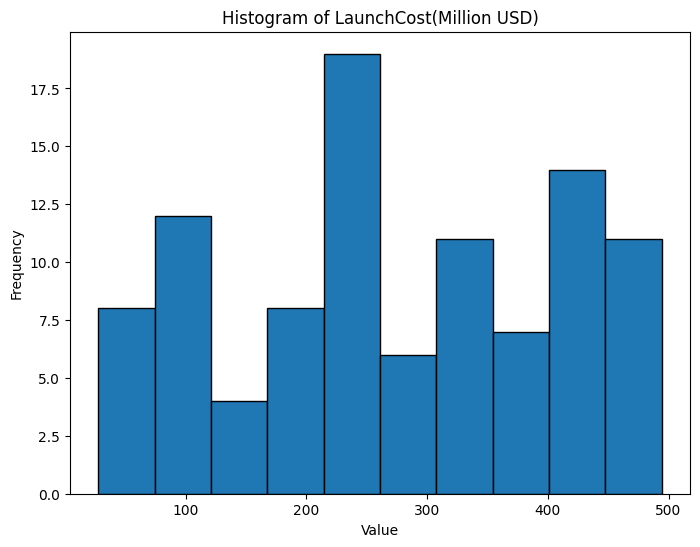

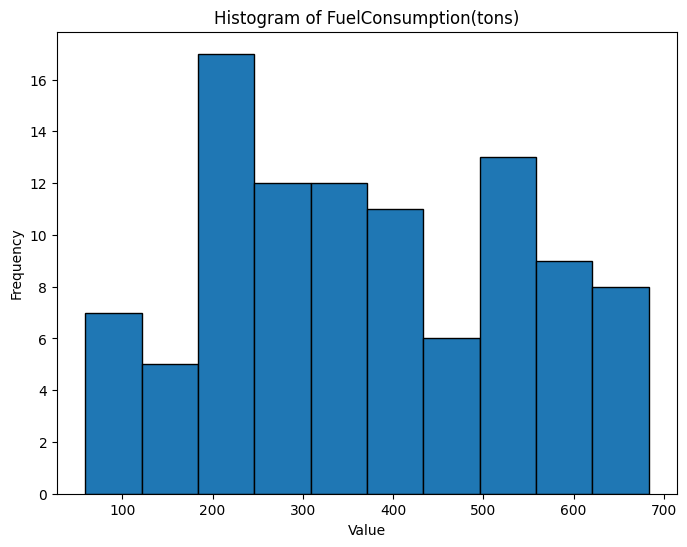

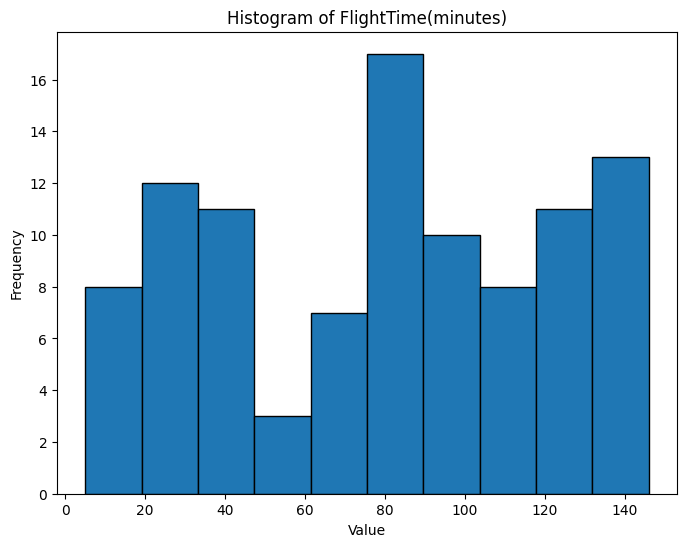

In [ ]:
# histogram for numerical values
for cols in numerical_cols:
  df[cols].plot(kind='hist', bins=10, edgecolor='black', figsize=(8, 6))
  plt.xlabel("Value")
  plt.ylabel("Frequency")
  plt.title(f"Histogram of {cols}")
  plt.show()


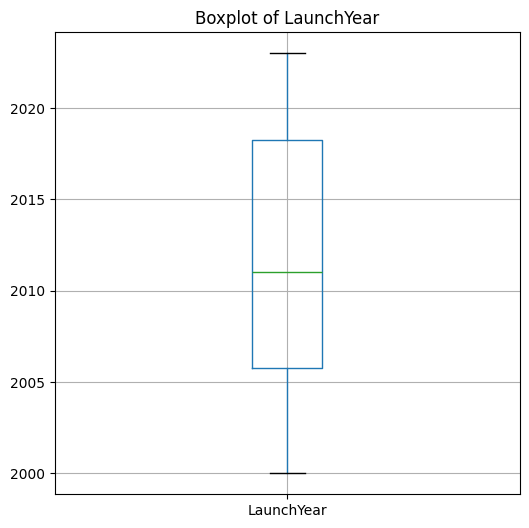

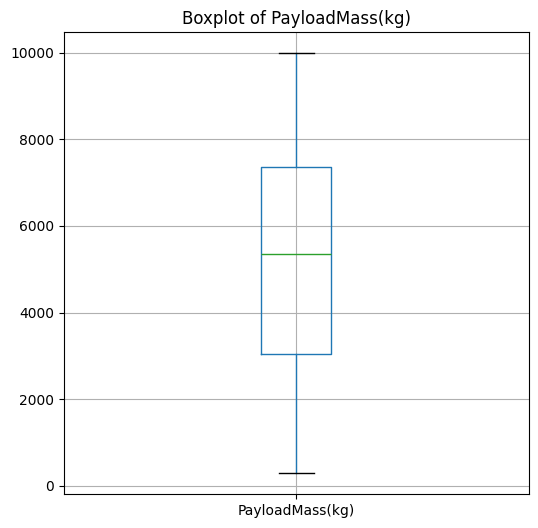

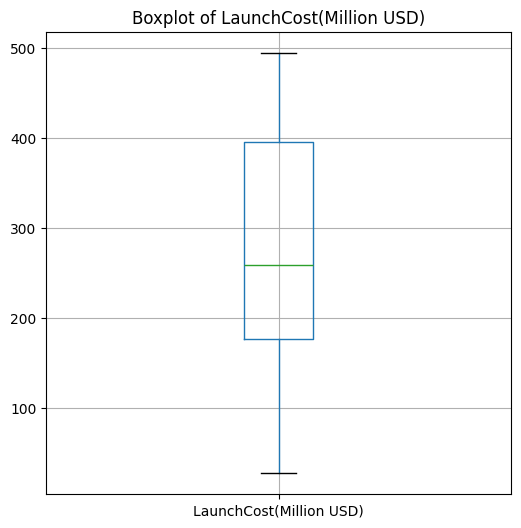

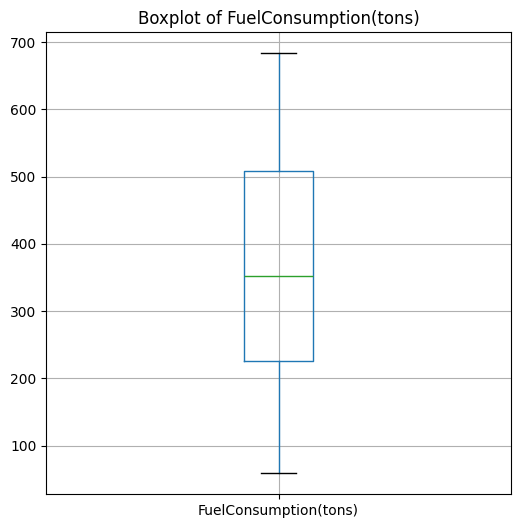

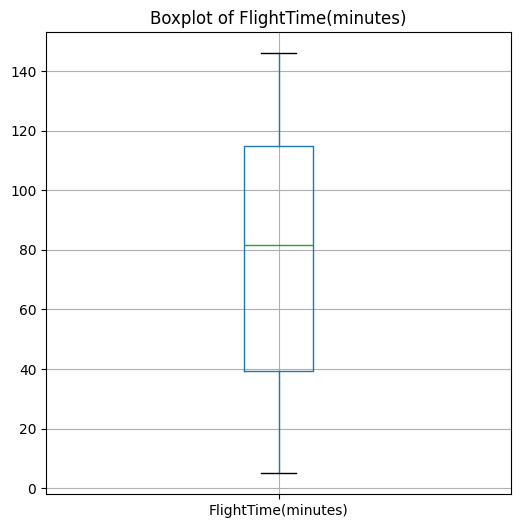

In [ ]:
# Box plot
for cols in numerical_cols:
  df.boxplot(column=cols, figsize=(6, 6))
  plt.title(f"Boxplot of {cols}")
  plt.show()


Module 2 Probability Distributions & Bayes Theorem

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
# Selecting numerical features and target variable
numerical_features = ["PayloadMass(kg)", "LaunchCost(Million USD)", "FuelConsumption(tons)", "FlightTime(minutes)"]
target = "MissionSuccess"
# Convert categorical target variable into binary (1 = Success, 0 = Failure)
df[target] = df[target].map({"Success": 1, "Failure": 0})
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df[numerical_features], df[target], test_size=0.2, random_state=42)
# Initialize and train Gaussian Naïve Bayes for each feature separately
for feature in numerical_features:
    print(f"Applying Bayes' Theorem on {feature}...")
    # Reshape feature column to fit Naïve Bayes
    X_train_feature = X_train[[feature]]
    X_test_feature = X_test[[feature]]
    # Train Gaussian Naïve Bayes
    gnb = GaussianNB()
    gnb.fit(X_train_feature, y_train)
    # Predict
    y_pred = gnb.predict(X_test_feature)
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy for {feature}: {accuracy * 100:.2f}%")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("-" * 50)

Applying Bayes' Theorem on PayloadMass(kg)...
Accuracy for PayloadMass(kg): 55.00%
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.89      0.64         9
           1       0.75      0.27      0.40        11

    accuracy                           0.55        20
   macro avg       0.62      0.58      0.52        20
weighted avg       0.64      0.55      0.51        20

--------------------------------------------------
Applying Bayes' Theorem on LaunchCost(Million USD)...
Accuracy for LaunchCost(Million USD): 55.00%
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.78      0.61         9
           1       0.67      0.36      0.47        11

    accuracy                           0.55        20
   macro avg       0.58      0.57      0.54        20
weighted avg       0.59      0.55      0.53        20

--------------------------------------------------
Applying Bayes

Probability distributions

[0.52 0.48]


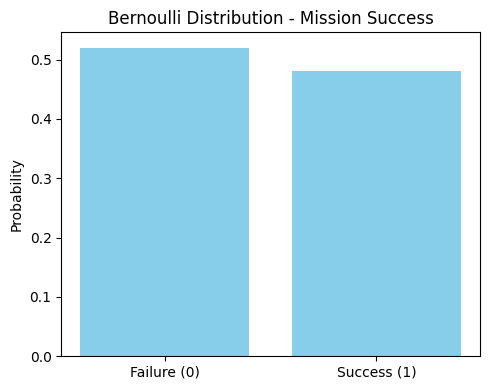

In [ ]:
if 'MissionSuccess' in df.columns:
    p = df['MissionSuccess'].mean()
    pmf = bernoulli.pmf([0, 1], p)
    print(pmf)
    plt.figure(figsize=(5, 4))
    plt.bar(['Failure (0)', 'Success (1)'], pmf, color='skyblue')
    plt.title("Bernoulli Distribution - Mission Success")
    plt.ylabel("Probability")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'MissionSuccess' not found.")

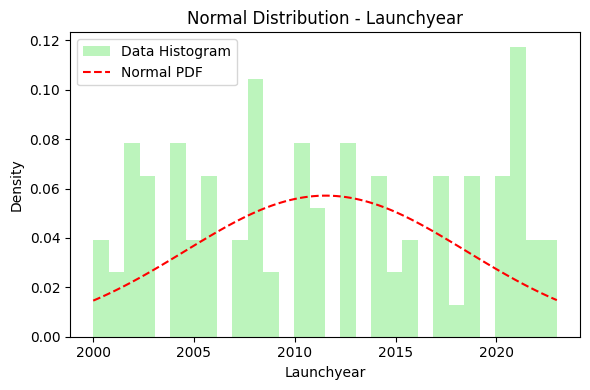

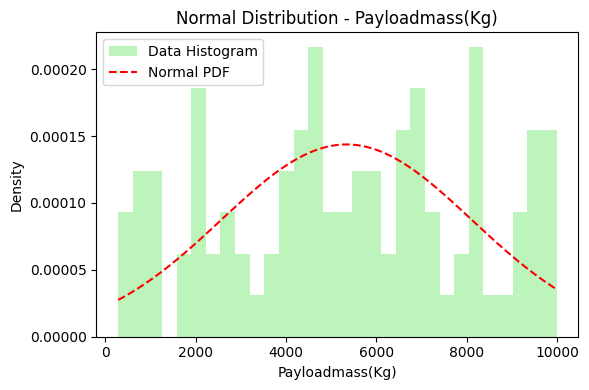

In [ ]:
normal_columns = ['LaunchYear', 'PayloadMass(kg)']

for col in normal_columns:
    if col in df.columns:
        data = df[col].dropna()
        mean, std = data.mean(), data.std()

        plt.figure(figsize=(6, 4))
        plt.hist(data, bins=30, density=True, alpha=0.6, color='lightgreen', label='Data Histogram')
        x = np.linspace(data.min(), data.max(), 100)
        plt.plot(x, norm.pdf(x, mean, std), 'r--', label='Normal PDF')
        plt.title(f"Normal Distribution - {col.replace('_', ' ').title()}")
        plt.xlabel(col.replace('_', ' ').title())
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{col}' not found.")

Module 3 - Correlation and Regression

Correlation Matrix:
                          LaunchYear  PayloadMass(kg)  LaunchCost(Million USD)  \
LaunchYear                 1.000000         0.105550                -0.108753   
PayloadMass(kg)            0.105550         1.000000                 0.011999   
LaunchCost(Million USD)   -0.108753         0.011999                 1.000000   
FuelConsumption(tons)     -0.174949        -0.110022                 0.031447   
FlightTime(minutes)        0.013790         0.114337                -0.047966   
MissionSuccess            -0.024316         0.130079                -0.052504   

                         FuelConsumption(tons)  FlightTime(minutes)  \
LaunchYear                           -0.174949             0.013790   
PayloadMass(kg)                      -0.110022             0.114337   
LaunchCost(Million USD)               0.031447            -0.047966   
FuelConsumption(tons)                 1.000000             0.049919   
FlightTime(minutes)                   0.049919          

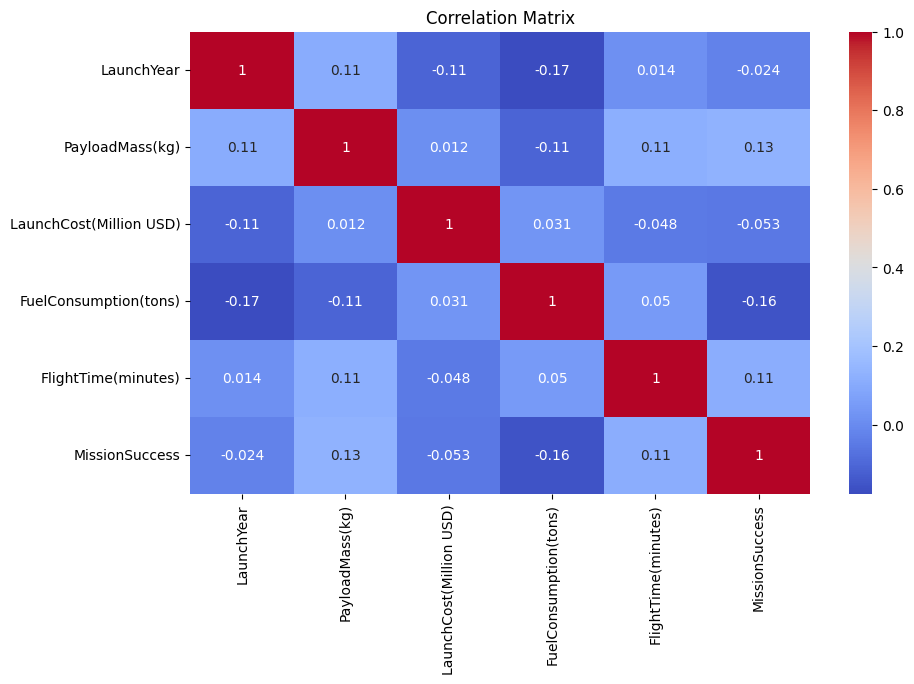

In [ ]:
correlation_matrix = df.corr(numeric_only=True)
print("Correlation Matrix:\n", correlation_matrix)
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


Intercept: 268.747821257532
Coefficient: 0.0005838301765263992


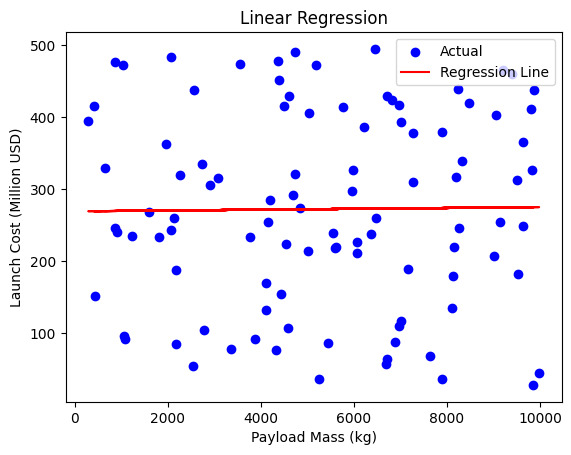

In [ ]:
# Single Feature
from sklearn.linear_model import LinearRegression
import numpy as np
X = df[['PayloadMass(kg)']]
y = df['LaunchCost(Million USD)']
# Initialize and fit model
model = LinearRegression()
model.fit(X, y)
# Print coefficients
print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_[0]}")
# Predict values
y_pred = model.predict(X)
# Plot regression line
plt.scatter(X, y, color='blue', label='Actual')
plt.plot(X, y_pred, color='red', label='Regression Line')
plt.xlabel('Payload Mass (kg)')
plt.ylabel('Launch Cost (Million USD)')
plt.title('Linear Regression')
plt.legend()
plt.show()


Target Column: LaunchYear
MAE: 6.36
MSE: 59.88
RMSE: 7.74


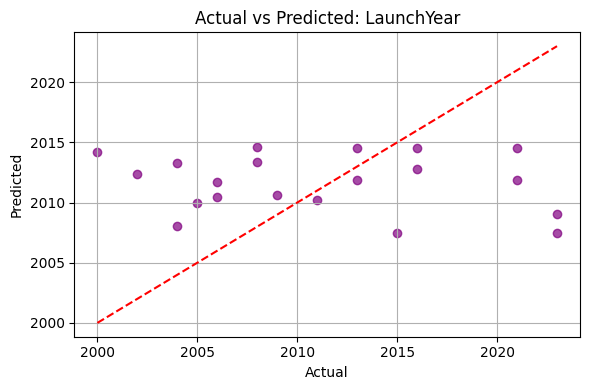


Target Column: PayloadMass(kg)
MAE: 1874.84
MSE: 6500955.04
RMSE: 2549.70


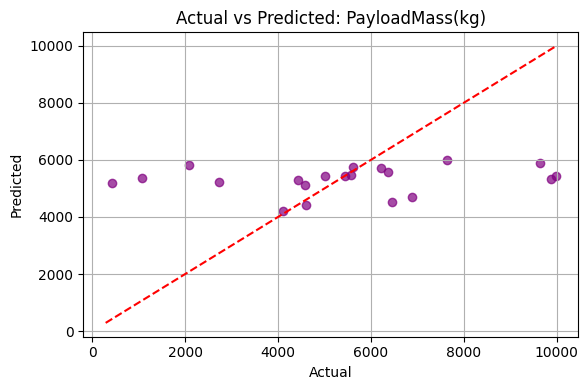


Target Column: LaunchCost(Million USD)
MAE: 141.40
MSE: 23227.78
RMSE: 152.41


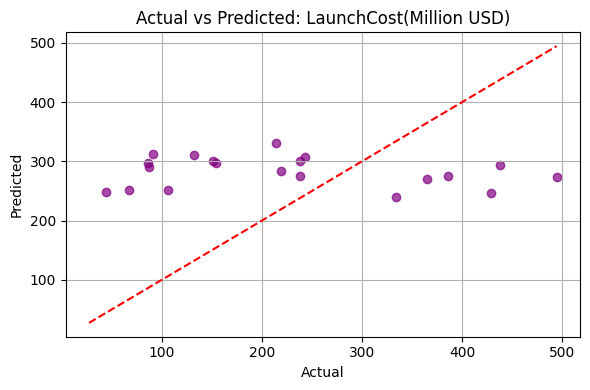


Target Column: FuelConsumption(tons)
MAE: 166.27
MSE: 35153.11
RMSE: 187.49


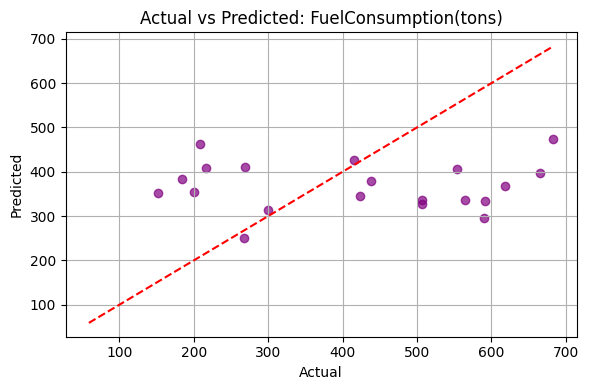


Target Column: FlightTime(minutes)
MAE: 32.06
MSE: 1432.75
RMSE: 37.85


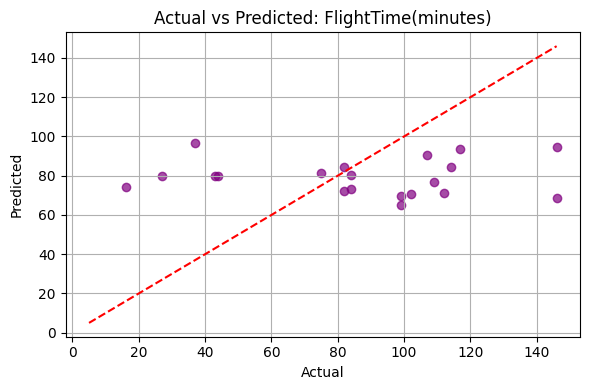


Target Column: MissionSuccess
MAE: 0.46
MSE: 0.22
RMSE: 0.47


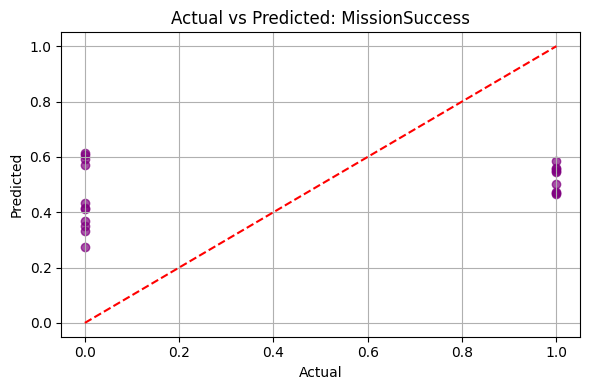

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
numeric_df = df.select_dtypes(include=[np.number]).dropna()
for target_col in numeric_df.columns:
    print(f"\nTarget Column: {target_col}")
    X = numeric_df.drop(columns=[target_col])
    y = numeric_df[target_col]
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    # Model training
    model = LinearRegression()
    model.fit(X_train, y_train)
    # Prediction
    y_pred = model.predict(X_test)
    # Evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, y_pred, alpha=0.7, color='purple')
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Actual vs Predicted: {target_col}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



--- T-Tests: Numerical Columns vs. Mission Success ---

T-test for LaunchYear (Success vs Failure): p-value = nan


<ipython-input-33-c5bf94c38950>:15: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_val = stats.ttest_ind(success_data, failure_data, equal_var=False)


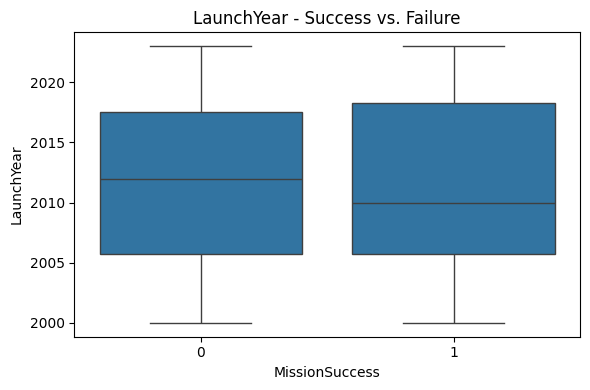

<ipython-input-33-c5bf94c38950>:15: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_val = stats.ttest_ind(success_data, failure_data, equal_var=False)


T-test for PayloadMass(kg) (Success vs Failure): p-value = nan


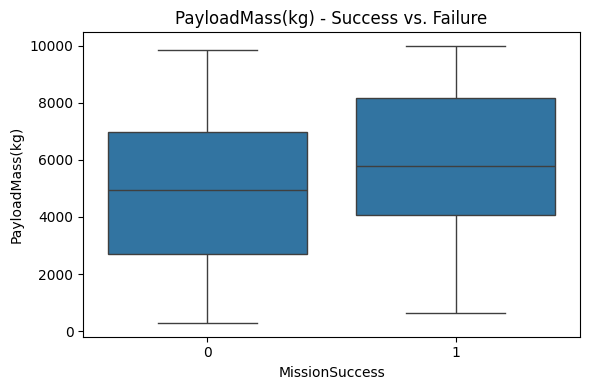

<ipython-input-33-c5bf94c38950>:15: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_val = stats.ttest_ind(success_data, failure_data, equal_var=False)


T-test for LaunchCost(Million USD) (Success vs Failure): p-value = nan


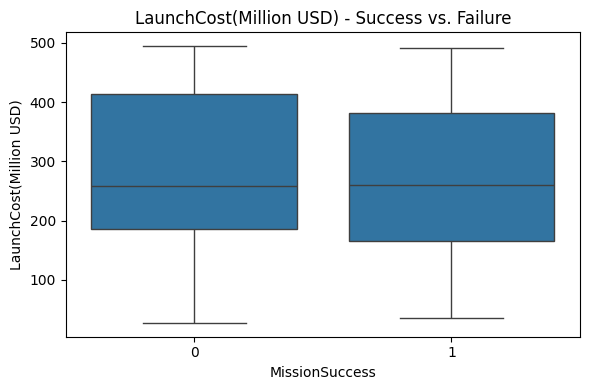

<ipython-input-33-c5bf94c38950>:15: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_val = stats.ttest_ind(success_data, failure_data, equal_var=False)


T-test for FuelConsumption(tons) (Success vs Failure): p-value = nan


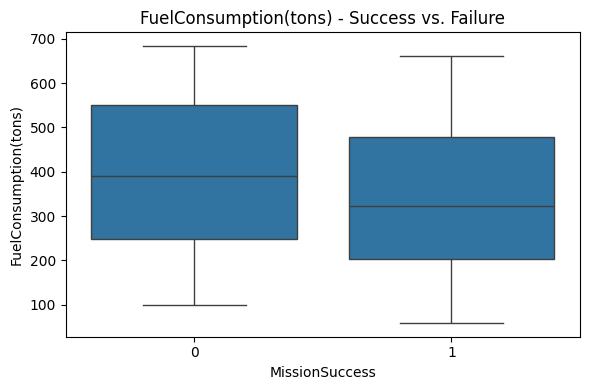

<ipython-input-33-c5bf94c38950>:15: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_val = stats.ttest_ind(success_data, failure_data, equal_var=False)


T-test for FlightTime(minutes) (Success vs Failure): p-value = nan


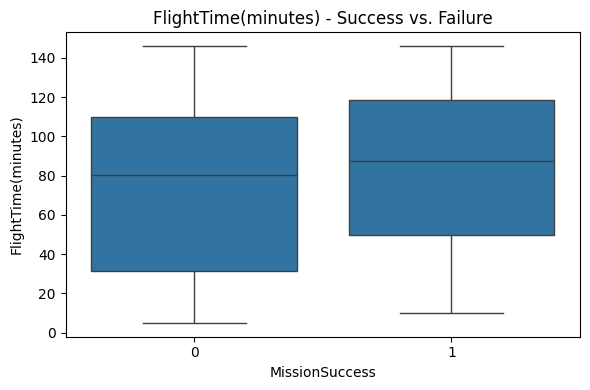


--- Chi-Square Tests: Categorical Columns vs. Mission Success ---

Chi-square test for RocketType vs. MissionSuccess: p-value = 0.2003


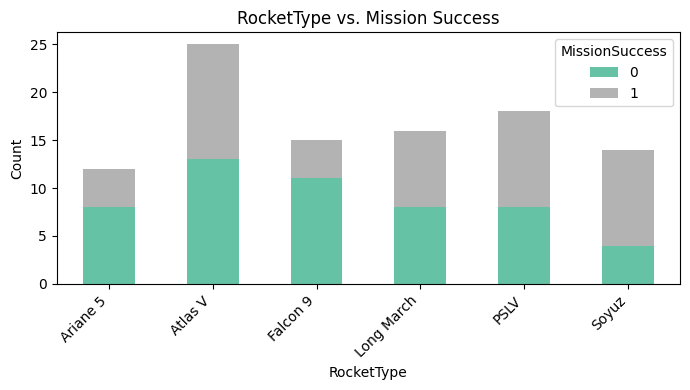

Chi-square test for OrbitType vs. MissionSuccess: p-value = 0.2451


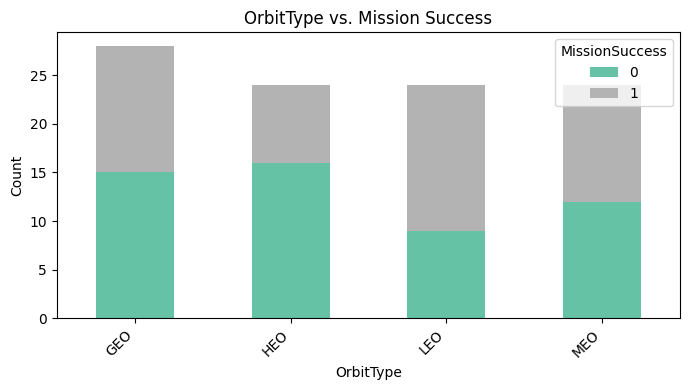

Chi-square test for Manufacturer vs. MissionSuccess: p-value = 0.5126


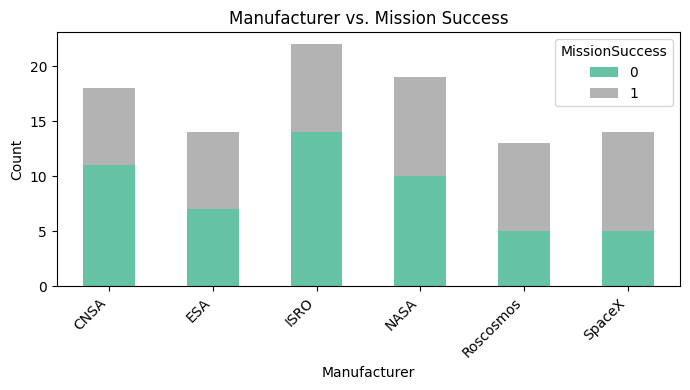


--- ANOVA: Numerical Columns across Manufacturers ---

ANOVA for LaunchYear across Manufacturers:
                      sum_sq    df        F    PR(>F)
C(Manufacturer)   585.263775   5.0  2.59403  0.030408
Residual         4241.646225  94.0      NaN       NaN



<ipython-input-33-c5bf94c38950>:55: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_val = anova_table["PR(>F)"][0]


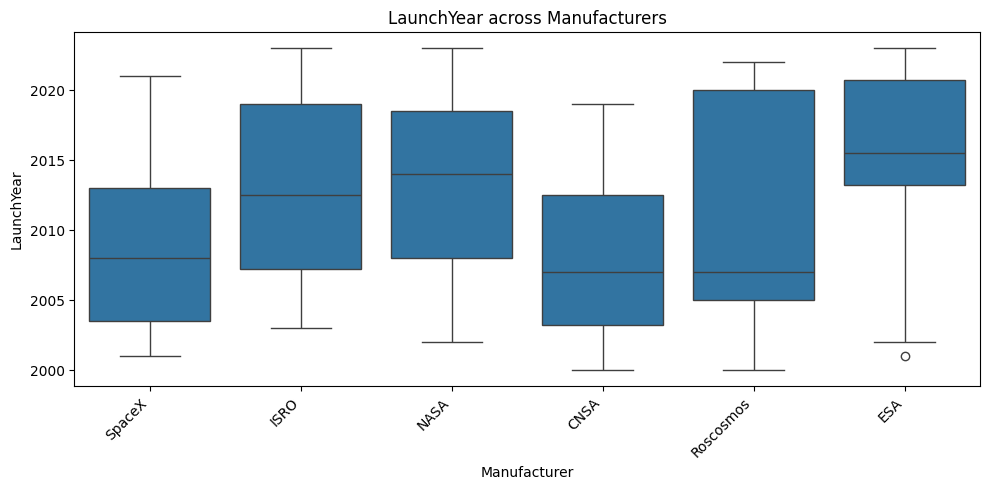

<ipython-input-33-c5bf94c38950>:55: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_val = anova_table["PR(>F)"][0]


ANOVA for PayloadMass(kg) across Manufacturers:
                       sum_sq    df         F    PR(>F)
C(Manufacturer)  1.485409e+07   5.0  0.373207  0.865888
Residual         7.482627e+08  94.0       NaN       NaN



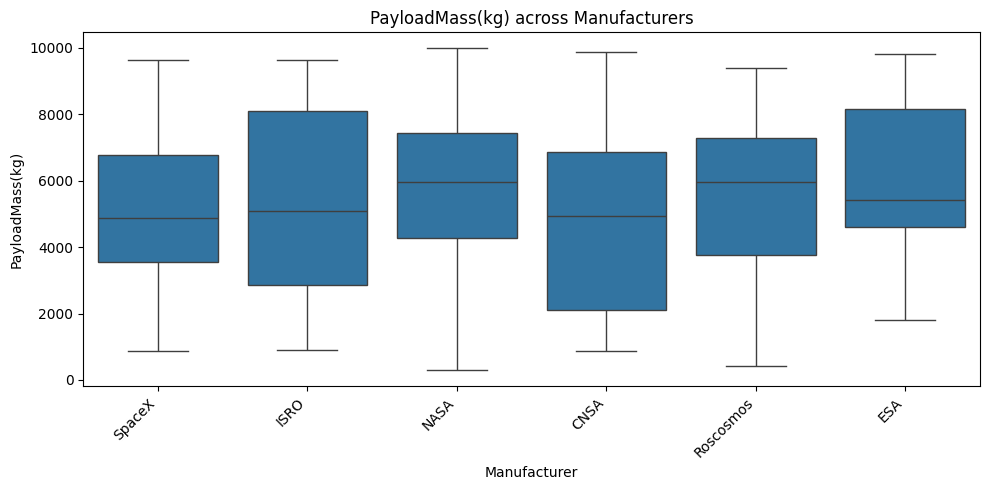

<ipython-input-33-c5bf94c38950>:55: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_val = anova_table["PR(>F)"][0]


ANOVA for LaunchCost(Million USD) across Manufacturers:
                       sum_sq    df         F    PR(>F)
C(Manufacturer)  2.767647e+04   5.0  0.292457  0.916049
Residual         1.779124e+06  94.0       NaN       NaN



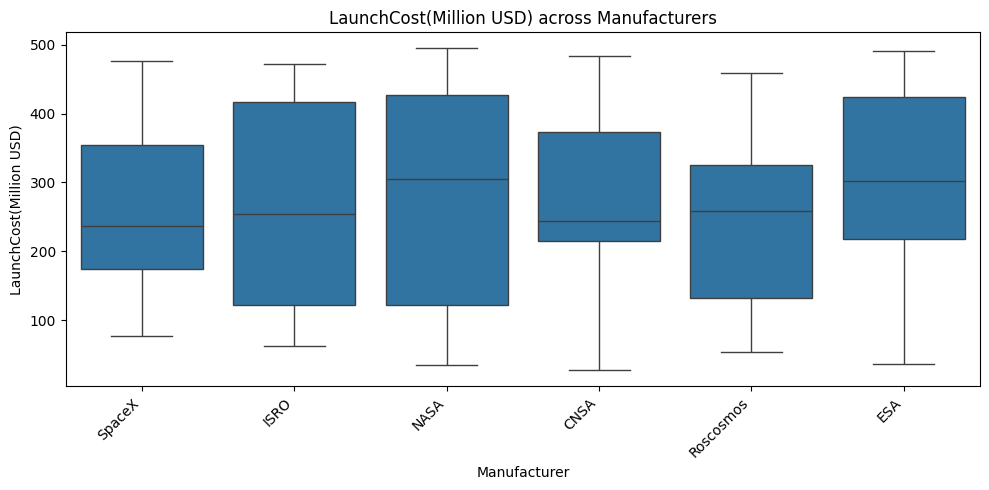

<ipython-input-33-c5bf94c38950>:55: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_val = anova_table["PR(>F)"][0]


ANOVA for FuelConsumption(tons) across Manufacturers:
                       sum_sq    df         F    PR(>F)
C(Manufacturer)  3.457413e+05   5.0  2.558305  0.032389
Residual         2.540720e+06  94.0       NaN       NaN



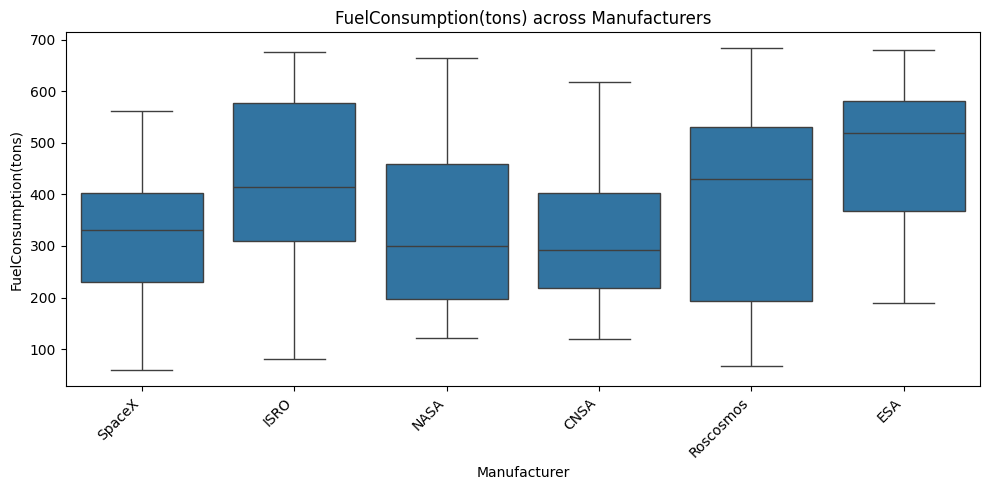

<ipython-input-33-c5bf94c38950>:55: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_val = anova_table["PR(>F)"][0]


ANOVA for FlightTime(minutes) across Manufacturers:
                        sum_sq    df         F    PR(>F)
C(Manufacturer)    5991.862229   5.0  0.667273  0.649196
Residual         168817.097771  94.0       NaN       NaN



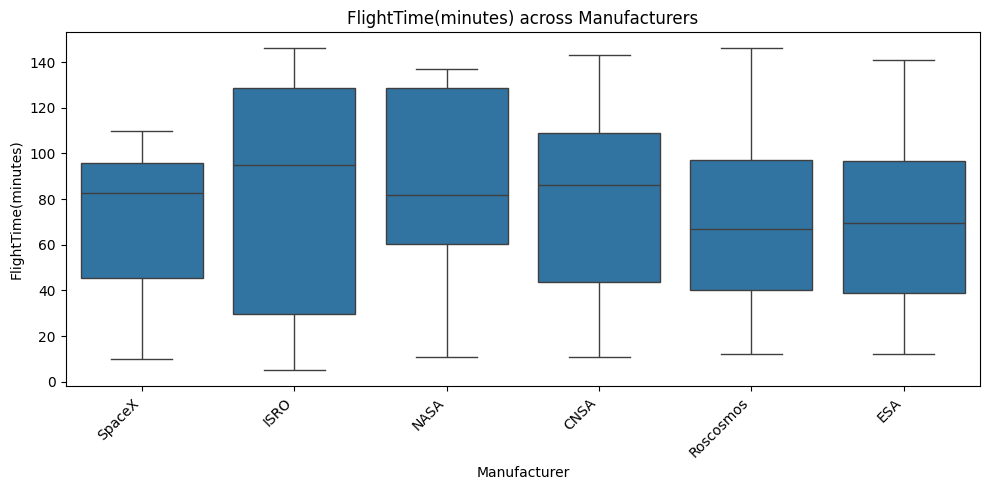


=== SUMMARY TABLE ===

 Test Type                Variable  P-Value Significant (p < 0.05)
    T-Test              LaunchYear      NaN                     No
    T-Test         PayloadMass(kg)      NaN                     No
    T-Test LaunchCost(Million USD)      NaN                     No
    T-Test   FuelConsumption(tons)      NaN                     No
    T-Test     FlightTime(minutes)      NaN                     No
Chi-square              RocketType 0.200272                     No
Chi-square               OrbitType 0.245087                     No
Chi-square            Manufacturer 0.512640                     No
     ANOVA              LaunchYear 0.030408                    Yes
     ANOVA         PayloadMass(kg) 0.865888                     No
     ANOVA LaunchCost(Million USD) 0.916049                     No
     ANOVA   FuelConsumption(tons) 0.032389                    Yes
     ANOVA     FlightTime(minutes) 0.649196                     No


In [ ]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
numerical_cols = ['LaunchYear', 'PayloadMass(kg)', 'LaunchCost(Million USD)',
                  'FuelConsumption(tons)', 'FlightTime(minutes)']
categorical_cols = ['RocketType', 'OrbitType', 'Manufacturer']
# --- 1. T-tests: Numerical columns vs. MissionSuccess ---
print("\n--- T-Tests: Numerical Columns vs. Mission Success ---\n")
t_test_results = []
for col in numerical_cols:
    success_data = df[df['MissionSuccess'] == 'Success'][col]
    failure_data = df[df['MissionSuccess'] == 'Failure'][col]
    t_stat, p_val = stats.ttest_ind(success_data, failure_data, equal_var=False)
    t_test_results.append((col, p_val))
    print(f"T-test for {col} (Success vs Failure): p-value = {p_val:.4f}")
    # Box plot
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='MissionSuccess', y=col, data=df)
    plt.title(f'{col} - Success vs. Failure')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
# --- 2. Chi-square: Categorical columns vs. MissionSuccess ---
print("\n--- Chi-Square Tests: Categorical Columns vs. Mission Success ---\n")
chi2_results = []
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['MissionSuccess'])
    chi2_stat, chi2_p, _, _ = stats.chi2_contingency(contingency_table)
    chi2_results.append((col, chi2_p))
    print(f"Chi-square test for {col} vs. MissionSuccess: p-value = {chi2_p:.4f}")
    # Bar chart
    contingency_table.plot(kind='bar', stacked=True, figsize=(7, 4), colormap='Set2')
    plt.title(f'{col} vs. Mission Success')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
# --- 3. ANOVA: Numerical columns grouped by Manufacturer ---
print("\n--- ANOVA: Numerical Columns across Manufacturers ---\n")
anova_results = []
for col in numerical_cols:
    anova = ols(f'Q("{col}") ~ C(Manufacturer)', data=df).fit()
    anova_table = sm.stats.anova_lm(anova, typ=2)
    p_val = anova_table["PR(>F)"][0]
    anova_results.append((col, p_val))
    print(f"ANOVA for {col} across Manufacturers:\n{anova_table}\n")
    # Box plot
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='Manufacturer', y=col, data=df)
    plt.title(f'{col} across Manufacturers')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
# --- 4. Summary Table ---
print("\n=== SUMMARY TABLE ===\n")
summary_df = pd.DataFrame({
    'Test Type': ['T-Test'] * len(t_test_results) + ['Chi-square'] * len(chi2_results) + ['ANOVA'] * len(anova_results),
    'Variable': [x[0] for x in t_test_results + chi2_results + anova_results],
    'P-Value': [x[1] for x in t_test_results + chi2_results + anova_results],
    'Significant (p < 0.05)': ['Yes' if x[1] < 0.05 else 'No' for x in t_test_results + chi2_results + anova_results]
})
print(summary_df.to_string(index=False))
